In [1]:
import numpy as np

input_data = np.load("D:\\1data\\FWINO_data\\train_samples\\sample_folder_1\\data\\data1.npy", allow_pickle=True)

In [3]:
input_data.size

175000000

In [4]:
input_data.shape

(500, 5, 1000, 70)

In [1]:
import numpy as np

In [3]:
input_data = np.load("D:\\1data\\FWINO_data\\train_samples\\sample_folder_1\\data\\data1.npy",allow_pickle=True)[0]

In [4]:
input_data = np.concat([input_data[i] for i in range(5)], axis=1)

In [5]:
input_data.shape

(1000, 350)

In [1]:
flag=1
if flag == 0:
    import numpy as np
    import matplotlib.pyplot as plt
    import pywt

    # 选择 db2 小波
    wavelet = pywt.Wavelet('haar')

    # 返回离散化后的尺度函数 φ(t) 和小波函数 ψ(t)
    # level=10 表示迭代次数，越大曲线越平滑
    phi, psi, x = wavelet.wavefun(level=10)

    plt.figure(figsize=(8, 4))
    plt.plot(x, phi, label="Scaling function φ(t)", color='steelblue')
    plt.plot(x, psi, label="Wavelet function ψ(t)", color='tomato')
    plt.title("Daubechies db2 Wavelet Basis Functions")
    plt.xlabel("t")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

if flag == 1:
    import numpy as np
    import matplotlib.pyplot as plt
    import dtcwt
    from scipy.signal import upfirdn

    # 选择 1D 双树复小波变换
    xfm = dtcwt.Transform1d()

In [7]:
xfm.biort

'near_sym_a'

In [5]:
xfm.qshift

'qshift_a'

AttributeError: module 'dtcwt' has no attribute 'biort'

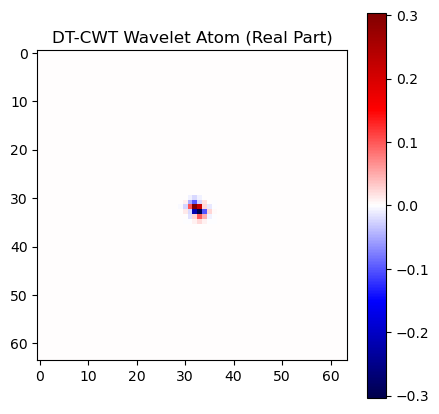

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import dtcwt

shape = (64, 64)    # 更小的画布更易看
nlevels = 1
t2d = dtcwt.Transform2d()
tmpl = t2d.forward(np.zeros(shape), nlevels=nlevels)

# 构造某方向的高频脉冲
hps = [np.zeros_like(hp, dtype=complex) for hp in tmpl.highpasses]
cy, cx = np.array(hps[0].shape[:2]) // 2
hps[0][cy, cx, 0] = 1.0 + 0j     # 第1层方向1

coeffs = type(tmpl)(lowpass=np.zeros_like(tmpl.lowpass), highpasses=hps)
atom = t2d.inverse(coeffs)       # 复数小波原子

plt.figure(figsize=(5,5))
plt.imshow(np.real(atom), cmap='seismic',
           vmin=-np.max(np.abs(atom)), vmax=np.max(np.abs(atom)))
plt.title("DT-CWT Wavelet Atom (Real Part)")
plt.colorbar()
plt.show()